In [1]:
import sys
import os

project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.append(project_root)

import ray
import json
import math
import torch
from fastparquet import ParquetFile
from pathlib import Path
import webdataset as wds
from itertools import islice

In [2]:
shard = Path("_shards_4")
shards_path = Path(f"/davinci-1/work/lbaroncelli/datacomp/{shard}")
tar_files = sorted([str(shards_path/s) for s in shards_path.glob("*.tar")])

In [3]:
from data_quality_pipeline.src.made.data_pipeline.steps.specificity_filtering  import SpecificityFilter

log_folder = Path("experiments/logs/")
config_path = Path("/davinci-1/home/fdimatteo/Progetti/fair_spoke_8/dev_branch/data_quality_pipeline/src/made/config.yaml")

ray.init(
    
    runtime_env={
        "working_dir": "/archive/SSD/home/fdimatteo/Progetti/fair_spoke_8/dev_branch",
        "env_vars": {
            "PYTHONPATH": "/archive/SSD/home/fdimatteo/Progetti/fair_spoke_8/dev_branch"
        }
    }
)


specificity_filter = SpecificityFilter.remote(config_path)

try:
    results = ray.get([
                    specificity_filter.execute.remote(tar_files, log_folder, get_specificities = True)
                   ])
except Exception as e:
    error_message = str(e)

ray.shutdown()

/archive/SSD/home/fdimatteo/Progetti/fair_spoke_8/dev_branch/data_quality_pipeline/src/made/data_pipeline/steps/specificity_filtering.py:190: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  @torch.cuda.amp.autocast(enabled=False)
2025-06-11 16:02:32,767	INFO worker.py:1888 -- Started a local Ray instance.
2025-06-11 16:02:32,887	INFO packaging.py:576 -- Creating a file package for local module '/archive/SSD/home/fdimatteo/Progetti/fair_spoke_8/dev_branch'.
2025-06-11 16:02:32,925	WARNING packaging.py:418 -- File /archive/SSD/home/fdimatteo/Progetti/fair_spoke_8/dev_branch/data_quality_pipeline/test/data/00000001_reduced.tar is very large (18.43MiB). Consider adding this file to the 'excludes' list to skip uploading it: `ray.init(..., runtime_env={'excludes': ['/archive/SSD/home/fdimatteo/Progetti/fair_spoke_8/dev_branch/data_quality_pipeline/test/data/00000001_reduced.tar']})`
2025-06-11 16:02:32,946	WARNING p

(SpecificityFilter pid=1276556) tensor([1.6539, 1.6414, 1.6011, 1.6670, 1.6541, 1.6274, 1.6530, 1.6642, 1.6046,
(SpecificityFilter pid=1276556)         1.6395, 1.6704, 1.6115, 1.6175, 1.6801, 1.5919, 1.6230, 1.6993, 1.6589,
(SpecificityFilter pid=1276556)         1.6619, 1.6661, 1.6904, 1.6401, 1.6387, 1.6096, 1.6115, 1.6751, 1.6119,
(SpecificityFilter pid=1276556)         1.6710, 1.6106, 1.7081, 1.6589, 1.5967], device='cuda:0')


In [4]:
len(results[0])

64

In [ ]:
try:
    if error_message:
        print("Error:", error_message)
except NameError:
    pass  

try:
    if results:
        print("Ray Output:", results)
except NameError:
    pass

In [3]:
from PIL import Image
import imageio.v2 as imageio
import io

dataset = (
    wds.WebDataset(tar_files)
    .decode(
        wds.handle_extension(".jpg", lambda value: Image.fromarray(imageio.imread(io.BytesIO(value)))),
        wds.handle_extension(".json", lambda value: json.loads(value.decode("utf-8")).get("uid", "unknown")),
        wds.handle_extension(".txt", lambda value: value.decode("utf-8").strip()),
    )
    .to_tuple("jpg", "json", "txt")  # Extract image, uid, and caption
    .batched(16)
)

/davinci-1/home/fdimatteo/.local/lib/python3.10/site-packages/webdataset/compat.py:389: UserWarning: WebDataset(shardshuffle=...) is None; set explicitly to False or a number
  warnings.warn(


In [4]:
batch = next(iter(dataset))
images, uids, captions = batch
print(len(images), len(uids), len(captions))

16 16 16


In [5]:
for i, o in enumerate(batch[0]):
    print(f"batch[1][{i}] type: {type(o)}")
    print(batch[0][o])

batch[1][0] type: <class 'PIL.Image.Image'>


TypeError: list indices must be integers or slices, not Image

In [6]:
from data_quality_pipeline.src.made.data_pipeline.data.datacomp_handler import decode_webdataset, get_next_batch
from PIL import Image

dataset = decode_webdataset(
    tar_files,
    get_images=True,
    get_captions=True,
    batch_size=32
)

all_uids = []
sample_count = 0
batch_id = 0
dataset_iter = iter(dataset)

while batch_id <2:
    batch = get_next_batch(dataset_iter)
    if batch is None:
        break

    batch_id += 1
    sample_count += len(batch[0])

    # Convert batch images to tensors, move them to device and encode them
    processed_images = [trs(im.convert("RGB")).to(device) for im in batch[0] if isinstance(im, Image.Image)]
    for i, im in enumerate(batch[1]):
        print(f"batch[1][{i}] type: {type(im)}")

    if not processed_images:
        print(f"Warning: batch {batch_id} contains no valid images after filtering. Skipping.")
        continue

    batch_images = torch.stack(processed_images)


batch[1][0] type: <class 'PIL.Image.Image'>
batch[1][1] type: <class 'PIL.Image.Image'>
batch[1][2] type: <class 'PIL.Image.Image'>
batch[1][3] type: <class 'PIL.Image.Image'>
batch[1][4] type: <class 'PIL.Image.Image'>
batch[1][5] type: <class 'PIL.Image.Image'>
batch[1][6] type: <class 'PIL.Image.Image'>
batch[1][7] type: <class 'PIL.Image.Image'>
batch[1][8] type: <class 'PIL.Image.Image'>
batch[1][9] type: <class 'PIL.Image.Image'>
batch[1][10] type: <class 'PIL.Image.Image'>
batch[1][11] type: <class 'PIL.Image.Image'>
batch[1][12] type: <class 'PIL.Image.Image'>
batch[1][13] type: <class 'PIL.Image.Image'>
batch[1][14] type: <class 'PIL.Image.Image'>
batch[1][15] type: <class 'PIL.Image.Image'>
batch[1][16] type: <class 'PIL.Image.Image'>
batch[1][17] type: <class 'PIL.Image.Image'>
batch[1][18] type: <class 'PIL.Image.Image'>
batch[1][19] type: <class 'PIL.Image.Image'>
batch[1][20] type: <class 'PIL.Image.Image'>
batch[1][21] type: <class 'PIL.Image.Image'>
batch[1][22] type: <

In [6]:
from data_quality_pipeline.src.made.data_pipeline.data.datacomp_handler import decode_webdataset, get_next_batch
from PIL import Image

dataset = decode_webdataset(
    tar_files,
    get_images=True,
    get_captions=True,
    batch_size=32
)

all_uids = []
sample_count = 0
batch_id = 0
dataset_iter = iter(dataset)

while batch_id < 2:
    batch = get_next_batch(dataset_iter)
    if batch is None:
        break

    batch_id += 1
    sample_count += len(batch[0])

    print(f"\n--- Batch {batch_id} ---")

    # Print UID elements (batch[1])
    print("UIDs (batch[1]):")
    for i, uid in enumerate(batch[0]):
        print(f"  [{i}] {uid} (type: {type(uid)})")

    # Print caption elements (batch[2])
    print("Captions (batch[2]):")
    for i, caption in enumerate(batch[2]):
        print(f"  [{i}] {caption} (type: {type(caption)})")

    # Process images
    processed_images = [trs(im.convert("RGB")).to(device) for im in batch[0] if isinstance(im, Image.Image)]

    if not processed_images:
        print(f"Warning: batch {batch_id} contains no valid images after filtering. Skipping.")
        continue

    batch_images = torch.stack(processed_images)



--- Batch 1 ---
UIDs (batch[1]):
  [0] 517d062077b7908e89dbe8d446053a3b (type: <class 'str'>)
  [1] c8950d00db67a21a7f7af2dc36d47b56 (type: <class 'str'>)
  [2] a38bd005a26b624dfb8e1e486e08c8f4 (type: <class 'str'>)
  [3] 2f98cdedc4b3ab83940eade5b09a0660 (type: <class 'str'>)
  [4] 07fea7d152fdd221ac2820b37b7c379b (type: <class 'str'>)
  [5] 283132a2c209078f338d60260ebbd3af (type: <class 'str'>)
  [6] 63bf469a60ead037f7df24ddd06ce262 (type: <class 'str'>)
  [7] 681af81412e933b0cdc87c0d7e68518d (type: <class 'str'>)
  [8] 71027f88e14ab7bedc64c3628c9299f0 (type: <class 'str'>)
  [9] 118c9623ede26dc8736c87637122754c (type: <class 'str'>)
  [10] be7beb17711ce31f078506ab3a62f7a8 (type: <class 'str'>)
  [11] a951d6756f428f186e7179b82aa027d6 (type: <class 'str'>)
  [12] 7420de3a6a6566b6ffee150c3107c1cf (type: <class 'str'>)
  [13] a9af912470694a7b20ecde2346e73f81 (type: <class 'str'>)
  [14] 51b9e6d77ef43fdb6565962a05af8332 (type: <class 'str'>)
  [15] e62a0d1c9fddd6fd6be21fcf9bcd374d (type:

In [7]:
from data_quality_pipeline.src.made.data_pipeline.model_hype import model_init
from data_quality_pipeline.src.made.data_pipeline.steps.specificity_filtering import specificity

ref_path = "/davinci-1/work/fdimatteo/hype_weights/reference.pt"
ref = torch.load(ref_path)
img_ref, txt_ref = ref["img"], ref["txt"]

model, trs = model_init(pretrained='/archive/SSD/home/fdimatteo/Progetti/fair_spoke_8/meru/hype/ckpt.pt')
curv = model.curvature.exp()
images_tensors = torch.stack([trs(im) for im in images])


model = model.cuda()
model = model.eval()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
images_tensors = images_tensors.to(device)

with torch.no_grad():
    images_feat = model.encode_image(images_tensors)
    images_spec = specificity(img_ref = img_ref, txt_ref = txt_ref, image=images_feat, curv=curv)


/archive/SSD/home/fdimatteo/Progetti/fair_spoke_8/dev_branch/data_quality_pipeline/src/made/data_pipeline/steps/specificity_filtering.py:189: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  @torch.cuda.amp.autocast(enabled=False)


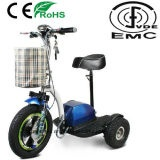

Vespa eléctrica barata de la movilidad con el Ce RoHS
Specificity:  tensor(0.2820, device='cuda:0')


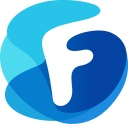

Notepad2 v4.22.07 简体中文绿色版（轻量级文本编辑器）插图1
Specificity:  tensor(0.2753, device='cuda:0')


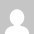

Staff Campestre
Specificity:  tensor(0.2385, device='cuda:0')


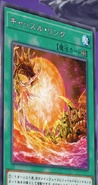

CastleLink-JP-Anime-VR
Specificity:  tensor(0.3003, device='cuda:0')


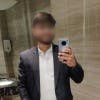

Käyttäjän Pateldixit04 profiilikuva
Specificity:  tensor(0.2875, device='cuda:0')


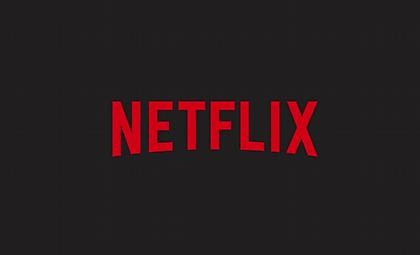

Αυτό είναι το νέο logo του Netflix - Το δούλευαν δύο ολόκληρα χρόνια
Specificity:  tensor(0.2590, device='cuda:0')


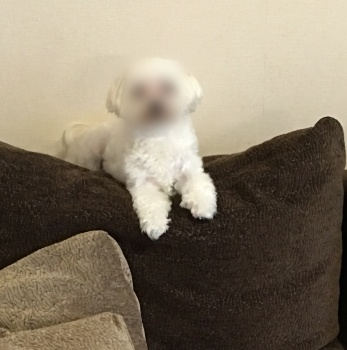

IMG_6238.jpg
Specificity:  tensor(0.2819, device='cuda:0')


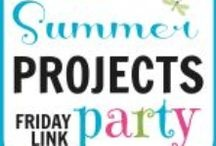

Summer Projects Series / Attacking home projects one at a time! Get ideas that you can use to check off some to-do projects on your list.
Specificity:  tensor(0.3010, device='cuda:0')


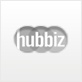

Kiva Dunes in Gulf Shores, AL 36542 Condominiums
Specificity:  tensor(0.2469, device='cuda:0')


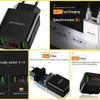

Fb img 1536650030335 scaled
Specificity:  tensor(0.2698, device='cuda:0')


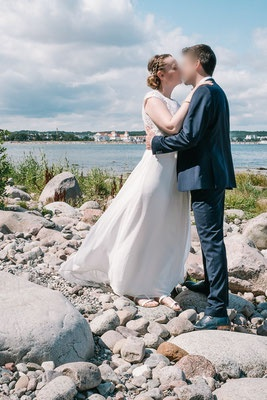

heiraten am Strand
Specificity:  tensor(0.3011, device='cuda:0')


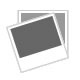

The New Hamlyn Crossword Dictionary,  | Paperback Book | Acceptable | 9780600576
Specificity:  tensor(0.2492, device='cuda:0')


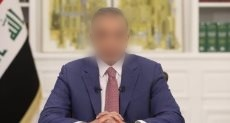

رئيس الوزراء العراقي مصطفى الكاظمي
Specificity:  tensor(0.2499, device='cuda:0')


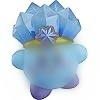

ねんどろいど 星のカービィ アイスカービィ ノンスケール ABS&amp;PVC製 塗装済み可動フィギュア
Specificity:  tensor(0.3168, device='cuda:0')


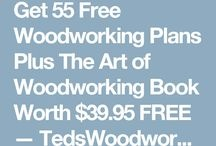

Wood
Specificity:  tensor(0.2246, device='cuda:0')


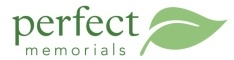

Save 10% at Perfect Memorials
Specificity:  tensor(0.2575, device='cuda:0')


In [8]:
for i,j,t in zip(images,captions,images_spec):
    display(i)
    print(j)
    print("Specificity: ", t)

In [9]:
a = torch.tensor(0.2820, device='cuda:0')
a>0.28

tensor(True, device='cuda:0')